# Imports

In [2]:
from data_explorer_class import DataExplorer 
from data_cleaning_class import DataCleaner
import pandas as pd
import numpy as np 
import lightgbm as lgb
import itertools
from sklearn.model_selection import GroupKFold , GridSearchCV 
from sklearn.metrics import mean_squared_error
pd.set_option('display.max_rows', None)
import os
import time

script_dir = os.getcwd()
train_path = os.path.join(script_dir , "train.csv")
test_path  = os.path.join(script_dir , "test.csv")
solution_path = os.path.join(script_dir,"solution.csv")


train_df  = pd.read_csv(train_path)
test_df   = pd.read_csv(test_path)
solution_path = pd.read_csv(solution_path)

# Preprocessing 

## Data Exploring ~ before cleaning

-----------------
DataSet Shape is (43584, 75)
-----------------
-----------------


=== STATISTICS ===
                age  jersey_number     height_cm     weight_kg  \
count  43584.000000   43584.000000  43584.000000  43584.000000   
mean      26.414648      13.472215    181.582760     75.814244   
std        4.036415       7.482398      6.332509      3.910184   
min       17.000000       1.000000    163.000000     65.000000   
25%       24.000000       7.000000    177.000000     73.000000   
50%       26.000000      13.000000    182.000000     76.000000   
75%       29.000000      20.000000    186.000000     78.000000   
99%       36.000000      26.000000    195.000000     84.000000   
max       39.000000      26.000000    200.000000     85.000000   

       market_value_eur    goals_team  goals_opponent  minutes_played  \
count      4.358400e+04  43584.000000    43584.000000    43584.000000   
mean       2.062389e+07      1.330213        1.330396       35.959090   
std        2.752

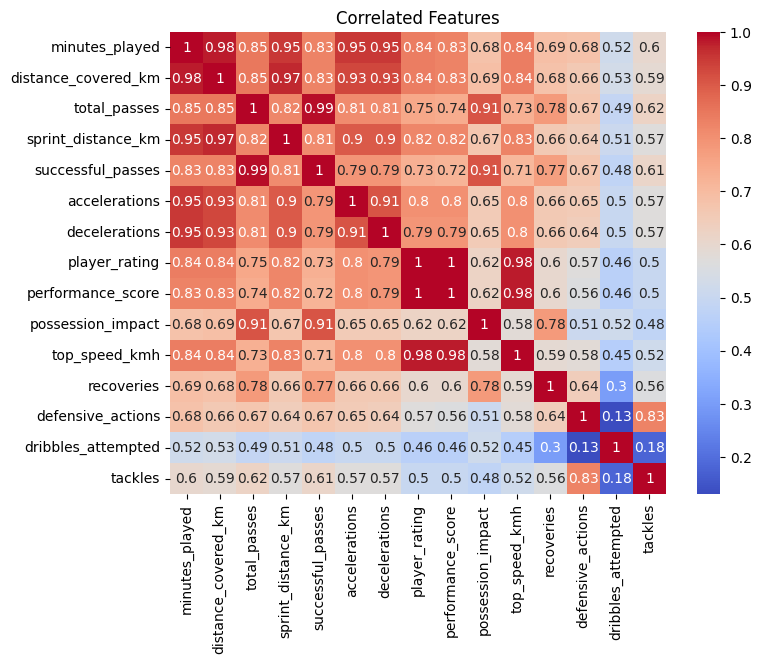


Correlation with player_rating
performance_score           0.996661
top_speed_kmh               0.979691
distance_covered_km         0.837534
minutes_played              0.837339
sprint_distance_km          0.821266
accelerations               0.799028
decelerations               0.794962
total_passes                0.745521
successful_passes           0.726532
possession_impact           0.623876
recoveries                  0.604887
defensive_actions           0.567453
stamina_score               0.557274
aerial_duels_won            0.535284
tackles                     0.503513
interceptions               0.466071
dribbles_attempted          0.462979
fouls_committed             0.448107
key_passes                  0.447832
clearances                  0.439657
crosses                     0.436741
aerial_duels_lost           0.428459
shots                       0.419941
fouls_suffered              0.419178
blocks                      0.340418
successful_dribbles         0.301617
total_

In [3]:
explore_df = DataExplorer(train_df)
explore_df.exploration()

## Data Cleaning

In [4]:
### removing zero minutes played rows
# print(train_df["minutes_played"].value_counts()) #there are 18524 of 0 minutes played rows
#remove zero minutes played rows since they contain no info- guess the model will get them if not but its easily hardcoded / predicted
train_df = train_df[train_df['minutes_played'] > 0].reset_index(drop=True) #


###dropping unrelated to performance cols
cols_to_drop = [
    'Id', 'player_name', 'match_id', 'match_date', 'stadium', 'city',
    'jersey_number', 'opponent_team', 'tournament_stage',
    'nationality', 'team', 'club_name','preferred_foot'
]
train_df = train_df.drop(columns= cols_to_drop)

print ("Positions are:")
print(train_df["position"].value_counts())

print ("Match results are")
print(train_df["match_result"].value_counts())

train_df = pd.get_dummies(train_df, columns=['position'], prefix='pos')
train_df = pd.get_dummies(train_df, columns=['match_result'], prefix='result')


train_df_cleaned = DataCleaner(train_df).clean_df()


Positions are:
position
Defender      9150
Midfielder    8147
Forward       6078
Goalkeeper    1685
Name: count, dtype: int64
Match results are
match_result
L    9230
W    9226
D    6604
Name: count, dtype: int64


### Exploring after cleaning 

-----------------
DataSet Shape is (25060, 67)
-----------------
-----------------


=== STATISTICS ===
                age     height_cm     weight_kg  market_value_eur  \
count  25060.000000  25060.000000  25060.000000      2.506000e+04   
mean      26.292618    181.162809     75.664725      2.106932e+07   
std        3.982329      6.223102      3.890573      2.802099e+07   
min       17.000000    163.000000     65.000000      5.288220e+05   
25%       24.000000    177.000000     73.000000      4.759435e+06   
50%       26.000000    182.000000     76.000000      1.059048e+07   
75%       29.000000    186.000000     78.000000      2.527637e+07   
99%       35.000000    194.000000     84.000000      1.420593e+08   
max       39.000000    200.000000     85.000000      2.000000e+08   

         goals_team  goals_opponent  minutes_played         goals  \
count  25060.000000    25060.000000    25060.000000  25060.000000   
mean       1.328811        1.328492       62.539545      0.096369  

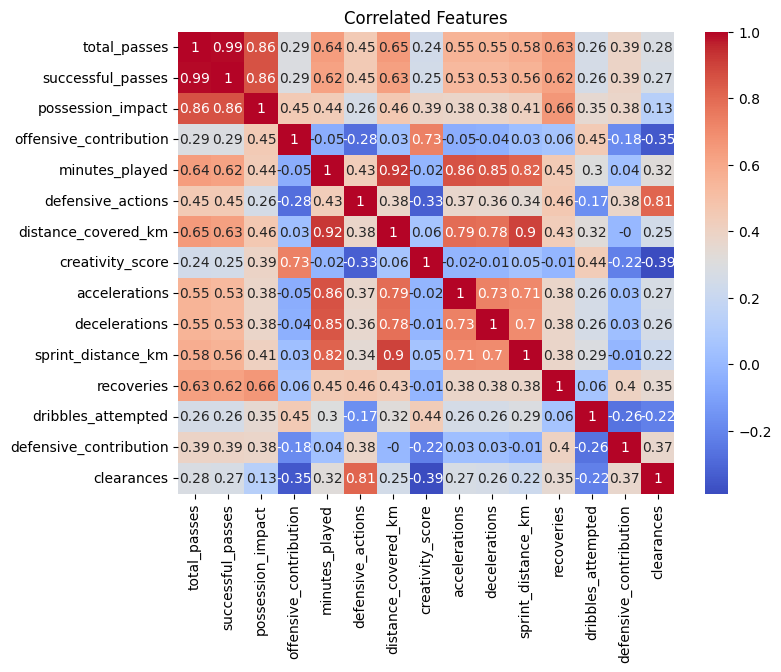


Correlation with player_rating
performance_score           0.926646
consistency_score           0.468972
pressure_resistance         0.443285
market_value_eur            0.409850
possession_impact           0.373480
offensive_contribution      0.342504
creativity_score            0.273214
total_passes                0.261418
successful_passes           0.252029
defensive_contribution      0.210164
goals                       0.185207
recoveries                  0.168782
dribbles_attempted          0.158449
successful_dribbles         0.152710
key_passes                  0.148117
shots                       0.142634
assists                     0.140080
player_of_match_awards      0.127195
stamina_score               0.119893
shots_on_target             0.116225
clutch_performance_score    0.089408
total_goals_tournament      0.085667
expected_assists_xa         0.070723
total_assists_tournament    0.067062
expected_goals_xg           0.064356
goals_team                  0.061323
goals_

In [5]:
cleaned_explorer = DataExplorer(train_df_cleaned).exploration()

### Feature Engineering

-----------------
DataSet Shape is (25060, 83)
-----------------
-----------------


=== STATISTICS ===
                age     height_cm     weight_kg  market_value_eur  \
count  25060.000000  25060.000000  25060.000000      2.506000e+04   
mean      26.292618    181.162809     75.664725      2.106932e+07   
std        3.982329      6.223102      3.890573      2.802099e+07   
min       17.000000    163.000000     65.000000      5.288220e+05   
25%       24.000000    177.000000     73.000000      4.759435e+06   
50%       26.000000    182.000000     76.000000      1.059048e+07   
75%       29.000000    186.000000     78.000000      2.527637e+07   
99%       35.000000    194.000000     84.000000      1.420593e+08   
max       39.000000    200.000000     85.000000      2.000000e+08   

         goals_team  goals_opponent  minutes_played         goals  \
count  25060.000000    25060.000000    25060.000000  25060.000000   
mean       1.328811        1.328492       62.539545      0.096369  

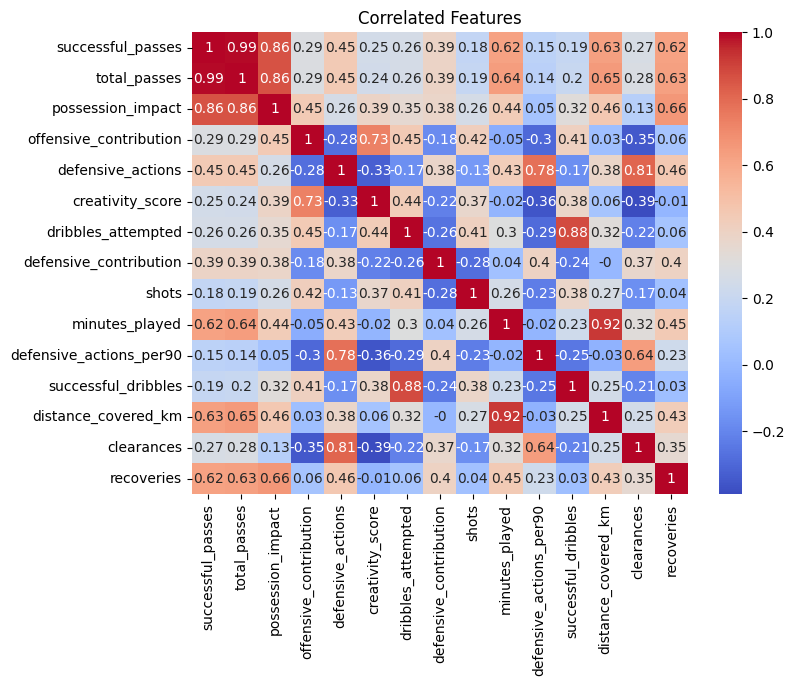


Correlation with player_rating
performance_score           0.926646
consistency_score           0.468972
pressure_resistance         0.443285
market_value_eur            0.409850
possession_impact           0.373480
offensive_contribution      0.342504
successful_passes_per90     0.320693
creativity_score            0.273214
total_passes                0.261418
successful_passes           0.252029
defensive_contribution      0.210164
goals                       0.185207
recoveries                  0.168782
goals_overperformance       0.165003
recoveries_per90            0.163570
dribbles_attempted          0.158449
successful_dribbles         0.152710
goals_per90                 0.152400
key_passes                  0.148117
dribbles_attempted_per90    0.143102
shots                       0.142634
assists                     0.140080
shot_conversion             0.135746
key_passes_per90            0.128456
dribble_success_rate        0.127639
player_of_match_awards      0.127195
shots_

In [6]:
#teams winning tend to have higher ratings
train_df_cleaned['goal_difference'] = (train_df_cleaned['goals_team'] - train_df_cleaned['goals_opponent'])

#i'm hoping that'll give a sense of the expected being the 'floor' of a player
train_df_cleaned['goals_overperformance'] = (train_df_cleaned['goals'] - train_df_cleaned['expected_goals_xg'])

train_df_cleaned['assist_overperformance'] = (train_df_cleaned['assists'] - train_df_cleaned['expected_assists_xa'])

#missing shots
train_df_cleaned['shot_conversion'] = np.where(train_df_cleaned['shots'] > 0,
    train_df_cleaned['goals'] / train_df_cleaned['shots']
    ,0
)

#Dribble success rate
train_df_cleaned['dribble_success_rate'] = np.where(
    train_df_cleaned['dribbles_attempted'] > 0,
    train_df_cleaned['successful_dribbles'] / train_df_cleaned['dribbles_attempted'],
    0
)

# per-90-minute normalization for key volume stats
per_90_cols = [
    'goals', 'assists', 'shots', 'shots_on_target', 'key_passes',
    'tackles', 'interceptions', 'recoveries', 'defensive_actions',
    'successful_passes', 'dribbles_attempted'
]

for col in per_90_cols:
    train_df_cleaned[f'{col}_per90'] = np.where(
        train_df_cleaned['minutes_played'] > 0,
        train_df_cleaned[col] / train_df_cleaned['minutes_played'] * 90,
        0
    )

cleaned_explorer = DataExplorer(train_df_cleaned).exploration() #okay all have good corelation with the result except for goals difference

## Preparing Test set

In [7]:
test_df = test_df.drop(columns= cols_to_drop)
test_df = pd.get_dummies(test_df, columns=['position'], prefix='pos')
test_df = pd.get_dummies(test_df, columns=['match_result'], prefix='result')

test_df_cleaned = DataCleaner(test_df).clean_df()

test_df_cleaned['goal_difference'] = (test_df_cleaned['goals_team'] - test_df_cleaned['goals_opponent'])
test_df_cleaned['goals_overperformance'] = (test_df_cleaned['goals'] - test_df_cleaned['expected_goals_xg'])
test_df_cleaned['assist_overperformance'] = (test_df_cleaned['assists'] - test_df_cleaned['expected_assists_xa'])
test_df_cleaned['shot_conversion'] = np.where(test_df_cleaned['shots'] > 0,
    test_df_cleaned['goals'] / test_df_cleaned['shots'], 0)
test_df_cleaned['dribble_success_rate'] = np.where(
    test_df_cleaned['dribbles_attempted'] > 0,
    test_df_cleaned['successful_dribbles'] / test_df_cleaned['dribbles_attempted'], 0)


# Models testing

## lightgbm

In [8]:
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# Separate features/target/groups
target = 'player_rating'
ID = ['player_id']  

X = train_df_cleaned.drop(columns=[target] + ID)
y = train_df_cleaned[target]
groups = train_df_cleaned['player_id']

gkf = GroupKFold(n_splits=5)

fold_scores = []
models = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(n_estimators= 2000, learning_rate= 0.03 , num_leaves= 31,
                            max_depth= -1 , min_child_samples= 20, subsample=0.8 , colsample_bytree= 0.8 , reg_alpha= 0.1,
                            reg_lambda= 0.1, random_state= 42
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores.append(mse)
    models.append(model)

print(f"\nMean CV MSE: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6440
[LightGBM] [Info] Number of data points in the train set: 20051, number of used features: 81
[LightGBM] [Info] Start training from score 6.297955
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009262 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6460
[LightGBM] [Info] Number of data points in the train set: 20051, number of used features: 81
[LightGBM] [Info] Start training from score 6.307202
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010765 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

## Random Forest

In [8]:
from sklearn.ensemble import RandomForestRegressor

fold_scores_rf = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = RandomForestRegressor(
        n_estimators=500, max_depth = 12 , min_samples_leaf = 5 , max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores_rf.append(mse)

print(f"\nMean CV MSE {np.mean(fold_scores_rf):.4f} (+/- {np.std(fold_scores_rf):.4f})")


Mean CV MSE 0.1380 (+/- 0.0051)


## XGBoost

In [9]:
import xgboost as xgb

fold_scores_xgb = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=6,                 # XGB default-ish, controls tree complexity directly (unlike LightGBM's leaf-wise growth)
        min_child_weight=5,          # analogous to min_child_samples — guards rare-event overfitting
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,               # XGB default L2 is already meaningful, keep it higher than alpha
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores_xgb.append(mse)

print(f"\nMean CV MSE : {np.mean(fold_scores_xgb):.4f} (+/- {np.std(fold_scores_xgb):.4f})")


Mean CV MSE : 0.0737 (+/- 0.0004)


In [9]:
from catboost import CatBoostRegressor

fold_scores_cb = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=2000, depth=6, l2_leaf_reg=3,random_seed=42,
        learning_rate=0.03,
        early_stopping_rounds=50,
        verbose=False
    )
    model.fit(X_train, y_train, eval_set=(X_val, y_val))

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores_cb.append(mse)

print(f"\nMean CV MSE {np.mean(fold_scores_cb):.4f} (+/- {np.std(fold_scores_cb):.4f})")


Mean CV MSE 0.0728 (+/- 0.0005)


## Hyperparameter search

### optuna catboost

In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import numpy as np

gkf = GroupKFold(n_splits=5)

def objective_cb_wide(trial):
    params = {
        'depth': trial.suggest_int('depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.003, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 30, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        'random_strength': trial.suggest_float('random_strength', 0.01, 20, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 5),
        'border_count': trial.suggest_categorical('border_count', [32, 64, 128, 254]),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 10),
    }

    fold_mses = []
    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(
            iterations=5000,
            task_type='GPU',
            random_seed=42,
            verbose=False,
            early_stopping_rounds=50,
            **params
        )
        model.fit(X_train, y_train, eval_set=(X_val, y_val))

        preds = model.predict(X_val)
        fold_mses.append(mean_squared_error(y_val, preds))

    return np.mean(fold_mses)

storage_name = "sqlite:///catboost_optuna_wide.db"

study_cb_wide = optuna.create_study(
    study_name="catboost_wide_search",
    direction='minimize',
    storage=storage_name,
    load_if_exists=True
)

study_cb_wide.optimize(objective_cb_wide, n_trials=500, show_progress_bar=True)

print("Best MSE:", study_cb_wide.best_value)
print("Best RMSE:", np.sqrt(study_cb_wide.best_value))
print("Best params:", study_cb_wide.best_params)

trials_df_cb_wide = study_cb_wide.trials_dataframe()
trials_df_cb_wide['rmse'] = np.sqrt(trials_df_cb_wide['value'])
trials_df_cb_wide = trials_df_cb_wide.sort_values('value')
trials_df_cb_wide.to_csv('catboost_optuna_wide_trials_v2.csv', index=False)
print(trials_df_cb_wide.head(10))

[I 2026-07-27 06:40:30,405] Using an existing study with name 'catboost_wide_search' instead of creating a new one.


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-07-27 06:41:26,114] Trial 1 finished with value: 0.07329625464551634 and parameters: {'depth': 6, 'learning_rate': 0.004479754365880425, 'l2_leaf_reg': 11.49723122497773, 'min_data_in_leaf': 48, 'random_strength': 1.1422014203636022, 'bagging_temperature': 0.7557418876263944, 'border_count': 254, 'grow_policy': 'Depthwise', 'leaf_estimation_iterations': 8}. Best is trial 1 with value: 0.07329625464551634.
[I 2026-07-27 06:41:29,544] Trial 2 finished with value: 0.07635315573285142 and parameters: {'depth': 4, 'learning_rate': 0.04375214009722012, 'l2_leaf_reg': 0.23107236881575502, 'min_data_in_leaf': 85, 'random_strength': 3.429761125586128, 'bagging_temperature': 1.2642072883528366, 'border_count': 32, 'grow_policy': 'Lossguide', 'leaf_estimation_iterations': 2}. Best is trial 1 with value: 0.07329625464551634.
[I 2026-07-27 06:41:46,761] Trial 3 finished with value: 0.07372433744436072 and parameters: {'depth': 6, 'learning_rate': 0.09015099282660818, 'l2_leaf_reg': 0.286176

### optuna xdg

In [25]:
import optuna
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import numpy as np

gkf = GroupKFold(n_splits=5)

def objective_xgb(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'tree_method': 'hist',
        'device': 'cuda',
    }

    fold_mses = []
    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBRegressor(
            n_estimators=5000,
            random_state=42,
            early_stopping_rounds=50,
            eval_metric='rmse',
            **params
        )
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict(X_val)
        fold_mses.append(mean_squared_error(y_val, preds))

    return np.mean(fold_mses)

storage_name = "sqlite:///xgboost_optuna.db"

study_xgb = optuna.create_study(
    study_name="xgboost_search",
    direction='minimize',
    storage=storage_name,
    load_if_exists=True
)

study_xgb.optimize(objective_xgb, n_trials=500, show_progress_bar=True)

print("Best MSE:", study_xgb.best_value)
print("Best RMSE:", np.sqrt(study_xgb.best_value))
print("Best params:", study_xgb.best_params)

trials_df_xgb = study_xgb.trials_dataframe()
trials_df_xgb['rmse'] = np.sqrt(trials_df_xgb['value'])
trials_df_xgb = trials_df_xgb.sort_values('value')
trials_df_xgb.to_csv('xgboost_optuna_trials.csv', index=False)
print(trials_df_xgb.head(10))

[I 2026-07-27 05:46:44,359] Using an existing study with name 'xgboost_search' instead of creating a new one.


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-07-27 05:46:46,616] Trial 4 finished with value: 0.07375092466540308 and parameters: {'max_depth': 8, 'learning_rate': 0.11770489680072463, 'min_child_weight': 33, 'subsample': 0.8765937997966077, 'colsample_bytree': 0.822748036269161, 'colsample_bylevel': 0.8314314054444505, 'reg_alpha': 8.463155347134084, 'reg_lambda': 0.02669982452717446, 'gamma': 0.817421331644736}. Best is trial 1 with value: 0.07334615375959032.
[I 2026-07-27 05:46:57,838] Trial 5 finished with value: 0.07411133842630693 and parameters: {'max_depth': 12, 'learning_rate': 0.006391429563081291, 'min_child_weight': 29, 'subsample': 0.5010585782109425, 'colsample_bytree': 0.8617150980877435, 'colsample_bylevel': 0.5421704974352966, 'reg_alpha': 1.071331532262329, 'reg_lambda': 0.01613601982512032, 'gamma': 2.2616183703739496}. Best is trial 1 with value: 0.07334615375959032.
[I 2026-07-27 05:46:59,966] Trial 6 finished with value: 0.07352089650726526 and parameters: {'max_depth': 12, 'learning_rate': 0.066620

KeyboardInterrupt: 